# Système de recommandation agricole - Modélisation

## Librairies nécessaires

In [5]:
# Import de base
import pandas as pd
import numpy as np
import sys,os, joblib
import matplotlib.pyplot as plt
import logging
sys.path.append(os.path.abspath(".."))

# Import scikit learn
from sklearn.model_selection import (train_test_split, KFold, cross_validate, GridSearchCV)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

# Import des autres modèles testés
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")
warnings.filterwarnings("ignore", message="Hint: Inferred schema contains integer")
warnings.filterwarnings("ignore", message="Saving scikit-learn models")

# Import mlflow
import mlflow
import mlflow.sklearn
mlflow.set_tracking_uri("file://" + os.path.abspath("../mlruns"))
from mlflow.tracking import MlflowClient
from mlflow.models.signature import infer_signature
# le warning pickle/sklearn de MLflow
# le warning pickle/sklearn de MLflow
logging.getLogger("mlflow.sklearn").setLevel(logging.ERROR)
# Import du projet
from scripts.preprocessing_pipeline import (
    separation_X_y,
    preparation_pipeline,
    cross_validation,
    train_predict
)

# Comparaison modèle sans optimisation sur le fichier consolidé

In [2]:
def mlflow_tracking_model(model, model_name, tags, projet_description):
    # =====================
    # Configuration MLflow
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("Agritech_Answers_Predictions")

    reg_name = "Forecaster_Global"
    mlflow.sklearn.autolog(log_models=False, log_datasets=False, silent=True)

    # =======================
    # Chargement des données
    # Dataset préparé mais NON encodé
    df = pd.read_csv("../data/processed/yield_df_final_conso_ready.csv")

    with mlflow.start_run(run_name=model_name, tags={
        "Training Info": tags,
        "Algorithm": model.__class__.__name__,
        "mlflow.note.content": projet_description
    }) as run:

        X_train, X_test, y_train, y_test, categorical_cols, numeric_cols = separation_X_y(df)

        # Pipeline & Cross-Validation
        pipeline = preparation_pipeline(
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
            model=model
        )

        cv_results = cross_validation(pipeline=pipeline, X_train=X_train, y_train=y_train)

        cv_metrics = {
            "cv_rmse_mean_kg": np.sqrt(-cv_results["test_mse"]).mean() / 10,
            "cv_rmse_std_kg": np.sqrt(-cv_results["test_mse"]).std() / 10,
            "cv_mae_mean_kg": (-cv_results["test_mae"]).mean() / 10,
            "cv_mae_std_kg": (-cv_results["test_mae"]).std() / 10,
            "cv_mape_mean": (-cv_results["test_mape"]).mean(),
            "cv_mape_std": (-cv_results["test_mape"]).std(),
            "cv_r2_mean": cv_results["test_r2"].mean(),
            "cv_r2_std": cv_results["test_r2"].std()
            }
        mlflow.log_metrics(cv_metrics)

        # Entraînement final
        pipeline.fit(X_train, y_train)

        # Prédictions test
        y_pred = pipeline.predict(X_test)

        prices_fao = {
            "cassava": 270, "maize": 260, "plantains_and_others": 480, "potatoes": 330,
            "rice": 360, "sorghum": 230, "soybean": 400, "sweet_potatoes": 420,
            "wheat": 200, "yams": 890, "barley": 220
        }

        results_df = pd.DataFrame({
            "actual": y_test,
            "pred": y_pred,
            "abs_error": np.abs(y_test - y_pred)
        }, index=X_test.index)

        # Avec OneHotEncoder, on récupère directement la culture brute
        results_df["crop"] = (
            X_test.loc[results_df.index, "item"]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        mae_by_item = (
            results_df.groupby("crop")["abs_error"]
            .mean()
            .sort_values()
        )

        mlflow.log_metrics({
            f"test_mae_{crop}_kg": float(mae / 10)
            for crop, mae in mae_by_item.items()
            })

        def calculate_monetary_error(row):
            price = prices_fao.get(row["crop"], 250)
            return (row["abs_error"] / 10000) * price

        results_df["error_cost_usd_ha"] = results_df.apply(calculate_monetary_error, axis=1)

        mean_economic_error = results_df["error_cost_usd_ha"].mean()
        rmse_hg = np.sqrt(mean_squared_error(y_test, y_pred))
        mae_hg = mean_absolute_error(y_test, y_pred)
        test_metrics = {
            "test_rmse_kg": rmse_hg / 10,
            "test_mae_kg": mae_hg / 10,
            "test_mape": mean_absolute_percentage_error(y_test, y_pred),
            "test_r2": r2_score(y_test, y_pred),
            "economic_error_usd_ha": mean_economic_error
        }
        mlflow.log_metrics(test_metrics)

        signature = infer_signature(X_test, y_pred)
        model_info = mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            signature=signature,
            registered_model_name=reg_name
        )

        client = MlflowClient()
        mv = model_info.registered_model_version

        full_description = (
            f"**Modèle :** {model_name}\n"
            f"**Note :** {projet_description}\n\n"
            f"**Scores CV (Moyenne ± Écart-type) :**\n"
            f"- CV R2: {cv_metrics['cv_r2_mean']:.4f} (± {cv_metrics['cv_r2_std']:.4f})\n"
            f"- CV RMSE: {cv_metrics['cv_rmse_mean_kg']:.2f} (± {cv_metrics['cv_rmse_std_kg']:.2f})\n\n"
            f"**Scores Test :**\n"
            f"- Test R2: {test_metrics['test_r2']:.4f}\n"
            f"- Test economic_error_usd_ha: {test_metrics['economic_error_usd_ha']:.4f}\n"
        )

        client.update_model_version(name=reg_name, version=mv, description=full_description)
        client.set_model_version_tag(reg_name, mv, "Algo", model.__class__.__name__)
        client.set_model_version_tag(reg_name, mv, "CV_R2", round(cv_metrics["cv_r2_mean"], 4))
        client.set_model_version_tag(reg_name, mv, "CV_Std", round(cv_metrics["cv_r2_std"], 4))
        

        print(f"\nVersion {mv} enregistrée.")
        print("\n=== Résultats métriques ===")
        print(f"CV RMSE : {cv_metrics['cv_rmse_mean_kg']:.4f} (± {cv_metrics['cv_rmse_std_kg']:.2f})")
        print(f"CV MAE  : {cv_metrics['cv_mae_mean_kg']:.4f} (± {cv_metrics['cv_mae_std_kg']:.4f})")
        print(f"CV R2   : {cv_metrics['cv_r2_mean']:.4f} (± {cv_metrics['cv_r2_std']:.4f})")
        print(f"Test RMSE : {test_metrics['test_rmse_kg']:.4f}")
        print(f"Test R2   : {test_metrics['test_r2']:.4f}")
        print(f"Test MAE  : {test_metrics['test_mae_kg']:.4f}")
        print(f"Test economic_error_usd_ha : {test_metrics['economic_error_usd_ha']:.4f}\n")

In [3]:
# DummyRegressor
model = DummyRegressor()
model_name = "DummyRegressor - Baseline"
tags = "DummyRegressor - Baseline"
projet_description = "Test d'un modèle DummyRegressor pour avoir une base sur laquelle comparer"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026/04/07 09:40:51 INFO mlflow.tracking.fluent: Experiment with name 'Agritech_Answers_Predictions' does not exist. Creating a new experiment.
2026-04-07 09:40:51,983 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 09:40:51,984 - INFO - Colonnes catégorielles : ['region', 'item', 'is_drought']
Successfully registered model 'Forecaster_Global'.
2026/04/07 09:40:58 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global, version 1



Version 1 enregistrée.

=== Résultats métriques ===
CV RMSE : 7604.3730 (± 187.80)
CV MAE  : 5578.7140 (± 93.2737)
CV R2   : -0.0002 (± 0.0002)
Test RMSE : 7216.6343
Test R2   : -0.0013
Test MAE  : 5378.3028
Test economic_error_usd_ha : 1680.7060

🏃 View run DummyRegressor - Baseline at: http://127.0.0.1:5000/#/experiments/3/runs/7c450f7a5cbf435b9941dc856cf994c1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


Created version '1' of model 'Forecaster_Global'.


In [4]:
# Modèle de régression linéaire
model = LinearRegression()
model_name = "LinearRegression - Baseline"
tags = "LinearRegression - Baseline"
projet_description = "Test d'un modèle LinearRegression sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-07 09:41:12,862 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 09:41:12,863 - INFO - Colonnes catégorielles : ['region', 'item', 'is_drought']
Registered model 'Forecaster_Global' already exists. Creating a new version of this model...
2026/04/07 09:41:18 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global, version 2



Version 2 enregistrée.

=== Résultats métriques ===
CV RMSE : 4840.4290 (± 55.16)
CV MAE  : 3233.5153 (± 58.2632)
CV R2   : 0.5943 (± 0.0143)
Test RMSE : 4805.9227
Test R2   : 0.5559
Test MAE  : 3201.1100
Test economic_error_usd_ha : 1033.3629

🏃 View run LinearRegression - Baseline at: http://127.0.0.1:5000/#/experiments/3/runs/8666a9133633470d8f16d09d6e001578
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


Created version '2' of model 'Forecaster_Global'.


In [5]:
# Modèle de RandomForest
model = RandomForestRegressor(random_state=42)
model_name = "RandomForest - Baseline"
tags = "RandomForest - Baseline"
projet_description = "Test d'un modèle Random Forest sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-07 09:41:29,396 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 09:41:29,397 - INFO - Colonnes catégorielles : ['region', 'item', 'is_drought']
Registered model 'Forecaster_Global' already exists. Creating a new version of this model...
2026/04/07 09:43:45 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global, version 3



Version 3 enregistrée.

=== Résultats métriques ===
CV RMSE : 1893.0226 (± 45.34)
CV MAE  : 894.9234 (± 4.1971)
CV R2   : 0.9378 (± 0.0051)
Test RMSE : 1729.6763
Test R2   : 0.9425
Test MAE  : 796.4869
Test economic_error_usd_ha : 273.6834

🏃 View run RandomForest - Baseline at: http://127.0.0.1:5000/#/experiments/3/runs/de8d0a8d0a4e49dbb900b352bd67c22e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


Created version '3' of model 'Forecaster_Global'.


In [6]:
# Modèle de XGBoost
model = xgb.XGBRegressor(random_state=42)
model_name = "XGBRegressor - Baseline"
tags = "XGBRegressor - Baseline"
projet_description = "Test d'un modèle XGBRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-07 09:44:00,318 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 09:44:00,318 - INFO - Colonnes catégorielles : ['region', 'item', 'is_drought']
Registered model 'Forecaster_Global' already exists. Creating a new version of this model...
2026/04/07 09:44:06 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global, version 4



Version 4 enregistrée.

=== Résultats métriques ===
CV RMSE : 2152.0037 (± 71.11)
CV MAE  : 1292.0533 (± 24.5055)
CV R2   : 0.9195 (± 0.0082)
Test RMSE : 2040.8158
Test R2   : 0.9199
Test MAE  : 1226.2530
Test economic_error_usd_ha : 406.6547

🏃 View run XGBRegressor - Baseline at: http://127.0.0.1:5000/#/experiments/3/runs/89aac5a3d45446278cf2e09a44f1df52
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


Created version '4' of model 'Forecaster_Global'.


In [7]:
# Modèle de LightGBM
model = lgb.LGBMRegressor(random_state=42, verbose=-1)
model_name = "LGBMRegressor - Baseline"
tags = "LGBMRegressor - Baseline"
projet_description = "Test d'un modèle LGBMRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-07 09:44:09,873 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 09:44:09,873 - INFO - Colonnes catégorielles : ['region', 'item', 'is_drought']
Registered model 'Forecaster_Global' already exists. Creating a new version of this model...
2026/04/07 09:44:18 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global, version 5



Version 5 enregistrée.

=== Résultats métriques ===
CV RMSE : 2689.7368 (± 50.00)
CV MAE  : 1708.5830 (± 30.6892)
CV R2   : 0.8745 (± 0.0095)
Test RMSE : 2679.5389
Test R2   : 0.8620
Test MAE  : 1675.0012
Test economic_error_usd_ha : 551.5749

🏃 View run LGBMRegressor - Baseline at: http://127.0.0.1:5000/#/experiments/3/runs/ae54338387654460aa0f21df863874f9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


Created version '5' of model 'Forecaster_Global'.


- Sur ces premiers tests, le modèle qui s'en sort le mieux sur l'ensemble des métriques (performance et métier) c'est celui de Random Forest.
- Les résultats de XGBoost et LightGBM sont exploitables pour essayer d'améliorer leur performance.
- Par contre le modèle de régression linéaire est trop loin en terme de performance. Au vu de la distribution de notre varibale cible, cela n'est pas étonnant.

# Comparaison modèle sans optimisation sur le fichier enrichi

In [9]:
def mlflow_tracking_model(model, model_name, tags, projet_description):
    # =====================
    # Configuration MLflow
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("Agritech_Answers_Predictions")

    reg_name = "Forecaster_Global"
    mlflow.sklearn.autolog(log_models=False, log_datasets=False, silent=True)

    # =======================
    # Chargement des données
    # Dataset préparé mais NON encodé
    df = pd.read_csv("../data/processed/yield_df_enriched_ready.csv")

    with mlflow.start_run(run_name=model_name, tags={
        "Training Info": tags,
        "Algorithm": model.__class__.__name__,
        "mlflow.note.content": projet_description
    }) as run:

        X_train, X_test, y_train, y_test, categorical_cols, numeric_cols = separation_X_y(df)

        # Pipeline & Cross-Validation
        pipeline = preparation_pipeline(
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
            model=model
        )

        cv_results = cross_validation(pipeline=pipeline, X_train=X_train, y_train=y_train)

        cv_metrics = {
            "cv_rmse_mean_kg": np.sqrt(-cv_results["test_mse"]).mean() / 10,
            "cv_rmse_std_kg": np.sqrt(-cv_results["test_mse"]).std() / 10,
            "cv_mae_mean_kg": (-cv_results["test_mae"]).mean() / 10,
            "cv_mae_std_kg": (-cv_results["test_mae"]).std() / 10,
            "cv_mape_mean": (-cv_results["test_mape"]).mean(),
            "cv_mape_std": (-cv_results["test_mape"]).std(),
            "cv_r2_mean": cv_results["test_r2"].mean(),
            "cv_r2_std": cv_results["test_r2"].std()
            }
        mlflow.log_metrics(cv_metrics)

        # Entraînement final
        pipeline.fit(X_train, y_train)

        # Prédictions test
        y_pred = pipeline.predict(X_test)

        prices_fao = {
            "cassava": 270, "maize": 260, "plantains_and_others": 480, "potatoes": 330,
            "rice": 360, "sorghum": 230, "soybean": 400, "sweet_potatoes": 420,
            "wheat": 200, "yams": 890, "barley": 220
        }

        results_df = pd.DataFrame({
            "actual": y_test,
            "pred": y_pred,
            "abs_error": np.abs(y_test - y_pred)
        }, index=X_test.index)

        # Avec OneHotEncoder, on récupère directement la culture brute
        results_df["crop"] = (
            X_test.loc[results_df.index, "item"]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        mae_by_item = (
            results_df.groupby("crop")["abs_error"]
            .mean()
            .sort_values()
        )

        mlflow.log_metrics({
            f"test_mae_{crop}_kg": float(mae / 10)
            for crop, mae in mae_by_item.items()
            })

        def calculate_monetary_error(row):
            price = prices_fao.get(row["crop"], 250)
            return (row["abs_error"] / 10000) * price

        results_df["error_cost_usd_ha"] = results_df.apply(calculate_monetary_error, axis=1)

        mean_economic_error = results_df["error_cost_usd_ha"].mean()
        rmse_hg = np.sqrt(mean_squared_error(y_test, y_pred))
        mae_hg = mean_absolute_error(y_test, y_pred)
        test_metrics = {
            "test_rmse_kg": rmse_hg / 10,
            "test_mae_kg": mae_hg / 10,
            "test_mape": mean_absolute_percentage_error(y_test, y_pred),
            "test_r2": r2_score(y_test, y_pred),
            "economic_error_usd_ha": mean_economic_error
        }
        mlflow.log_metrics(test_metrics)

        signature = infer_signature(X_test, y_pred)
        model_info = mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            signature=signature,
            registered_model_name=reg_name
        )

        client = MlflowClient()
        mv = model_info.registered_model_version

        full_description = (
            f"**Modèle :** {model_name}\n"
            f"**Note :** {projet_description}\n\n"
            f"**Scores CV (Moyenne ± Écart-type) :**\n"
            f"- CV R2: {cv_metrics['cv_r2_mean']:.4f} (± {cv_metrics['cv_r2_std']:.4f})\n"
            f"- CV RMSE: {cv_metrics['cv_rmse_mean_kg']:.2f} (± {cv_metrics['cv_rmse_std_kg']:.2f})\n\n"
            f"**Scores Test :**\n"
            f"- Test R2: {test_metrics['test_r2']:.4f}\n"
            f"- Test economic_error_usd_ha: {test_metrics['economic_error_usd_ha']:.4f}\n"
        )

        client.update_model_version(name=reg_name, version=mv, description=full_description)
        client.set_model_version_tag(reg_name, mv, "Algo", model.__class__.__name__)
        client.set_model_version_tag(reg_name, mv, "CV_R2", round(cv_metrics["cv_r2_mean"], 4))
        client.set_model_version_tag(reg_name, mv, "CV_Std", round(cv_metrics["cv_r2_std"], 4))
        

        print(f"\nVersion {mv} enregistrée.")
        print("\n=== Résultats métriques ===")
        print(f"CV RMSE : {cv_metrics['cv_rmse_mean_kg']:.4f} (± {cv_metrics['cv_rmse_std_kg']:.2f})")
        print(f"CV MAE  : {cv_metrics['cv_mae_mean_kg']:.4f} (± {cv_metrics['cv_mae_std_kg']:.4f})")
        print(f"CV R2   : {cv_metrics['cv_r2_mean']:.4f} (± {cv_metrics['cv_r2_std']:.4f})")
        print(f"Test RMSE : {test_metrics['test_rmse_kg']:.4f}")
        print(f"Test R2   : {test_metrics['test_r2']:.4f}")
        print(f"Test MAE  : {test_metrics['test_mae_kg']:.4f}")
        print(f"Test economic_error_usd_ha : {test_metrics['economic_error_usd_ha']:.4f}\n")

In [10]:
# DummyRegressor
model = DummyRegressor()
model_name = "DummyRegressor - Baseline - fichier enrichi"
tags = "DummyRegressor - Baseline - fichier enrichi"
projet_description = "Test d'un modèle DummyRegressor pour avoir une base sur laquelle comparer"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026-04-07 09:45:10,428 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 09:45:10,429 - INFO - Colonnes catégorielles : ['region', 'item', 'fertilizer_used', 'irrigation_used', 'weather_condition', 'soil_type', 'is_drought']
Registered model 'Forecaster_Global' already exists. Creating a new version of this model...
2026/04/07 09:45:14 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global, version 6



Version 6 enregistrée.

=== Résultats métriques ===
CV RMSE : 7604.3730 (± 187.80)
CV MAE  : 5578.7140 (± 93.2737)
CV R2   : -0.0002 (± 0.0002)
Test RMSE : 7216.6343
Test R2   : -0.0013
Test MAE  : 5378.3028
Test economic_error_usd_ha : 1680.7060

🏃 View run DummyRegressor - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/3/runs/73a289c6c54a42e19727488a1d2593a1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


Created version '6' of model 'Forecaster_Global'.


In [11]:
# Modèle de régression linéaire
model = LinearRegression()
model_name = "LinearRegression - Baseline - fichier enrichi"
tags = "LinearRegression - Baseline - fichier enrichi"
projet_description = "Test d'un modèle LinearRegression sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-07 09:45:21,622 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 09:45:21,623 - INFO - Colonnes catégorielles : ['region', 'item', 'fertilizer_used', 'irrigation_used', 'weather_condition', 'soil_type', 'is_drought']
Registered model 'Forecaster_Global' already exists. Creating a new version of this model...
2026/04/07 09:45:25 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global, version 7



Version 7 enregistrée.

=== Résultats métriques ===
CV RMSE : 4841.7110 (± 54.37)
CV MAE  : 3234.7068 (± 57.8159)
CV R2   : 0.5941 (± 0.0143)
Test RMSE : 4807.8225
Test R2   : 0.5556
Test MAE  : 3202.9833
Test economic_error_usd_ha : 1034.2202

🏃 View run LinearRegression - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/3/runs/b8069d226a34437dae0189c26b41fbd1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


Created version '7' of model 'Forecaster_Global'.


In [12]:
# Modèle de RandomForest
model = RandomForestRegressor(random_state=42)
model_name = "RandomForest - Baseline - fichier enrichi"
tags = "RandomForest - Baseline"
projet_description = "Test d'un modèle Random Forest sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-07 09:45:29,138 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 09:45:29,138 - INFO - Colonnes catégorielles : ['region', 'item', 'fertilizer_used', 'irrigation_used', 'weather_condition', 'soil_type', 'is_drought']
Registered model 'Forecaster_Global' already exists. Creating a new version of this model...
2026/04/07 09:48:57 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global, version 8



Version 8 enregistrée.

=== Résultats métriques ===
CV RMSE : 1926.1649 (± 66.57)
CV MAE  : 950.5381 (± 12.3603)
CV R2   : 0.9355 (± 0.0065)
Test RMSE : 1748.9721
Test R2   : 0.9412
Test MAE  : 856.2829
Test economic_error_usd_ha : 291.8239

🏃 View run RandomForest - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/3/runs/3acd7ba6a3b2442da1eef6c5c9bc6bb8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


Created version '8' of model 'Forecaster_Global'.


In [14]:
# Modèle de XGBoost
model = xgb.XGBRegressor(random_state=42)
model_name = "XGBRegressor - Baseline - fichier enrichi"
tags = "XGBRegressor - Baseline - fichier enrichi"
projet_description = "Test d'un modèle XGBRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026-04-07 09:49:48,024 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 09:49:48,025 - INFO - Colonnes catégorielles : ['region', 'item', 'fertilizer_used', 'irrigation_used', 'weather_condition', 'soil_type', 'is_drought']
Registered model 'Forecaster_Global' already exists. Creating a new version of this model...
2026/04/07 09:49:52 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global, version 10



Version 10 enregistrée.

=== Résultats métriques ===
CV RMSE : 2179.0641 (± 44.71)
CV MAE  : 1320.7450 (± 22.2847)
CV R2   : 0.9175 (± 0.0072)
Test RMSE : 2017.5085
Test R2   : 0.9217
Test MAE  : 1249.1880
Test economic_error_usd_ha : 413.5231

🏃 View run XGBRegressor - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/3/runs/86f5c32859954274b6ff4d02a5df2ccb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


Created version '10' of model 'Forecaster_Global'.


In [13]:
# Modèle de LightGBM
model = lgb.LGBMRegressor(random_state=42, verbose=-1)
model_name = "LGBMRegressor - Baseline - fichier enrichi"
tags = "LGBMRegressor - Baselzine - fichier enrichi"
projet_description = "Test d'un modèle LGBMRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026-04-07 09:49:36,592 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 09:49:36,592 - INFO - Colonnes catégorielles : ['region', 'item', 'fertilizer_used', 'irrigation_used', 'weather_condition', 'soil_type', 'is_drought']
Registered model 'Forecaster_Global' already exists. Creating a new version of this model...
2026/04/07 09:49:43 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global, version 9



Version 9 enregistrée.

=== Résultats métriques ===
CV RMSE : 2709.1046 (± 52.11)
CV MAE  : 1715.8439 (± 30.4070)
CV R2   : 0.8726 (± 0.0101)
Test RMSE : 2677.7113
Test R2   : 0.8621
Test MAE  : 1672.1599
Test economic_error_usd_ha : 553.9541

🏃 View run LGBMRegressor - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/3/runs/a2d425f7390b4b3283d43cabdf7426af
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


Created version '9' of model 'Forecaster_Global'.


# Optimisation des hyperparamètres sur RandomForest / XGBoost & LightGBM

A l'aide de gridsearchCV, on va essayer ici de trouver les meilleurs hyperparamètres pour chacun des modèles

In [4]:
def mlflow_tracking_gridsearch(model, model_name, param_grid, tags, projet_description):
    # =====================
    # Configuration MLflow
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("Agritech_Answers_Predictions")

    reg_name = "Yield_Forecaster_GridSearch"
    mlflow.sklearn.autolog(log_models=False, log_datasets=False, silent=True, max_tuning_runs=0)

    # =======================
    # Chargement des données
    df = pd.read_csv("../data/processed/yield_df_final_conso_ready.csv")

    with mlflow.start_run(run_name=model_name, tags={
        "Training Info": tags,
        "Algorithm": model.__class__.__name__,
        "mlflow.note.content": projet_description
    }) as run:

        mlflow.set_tag("target_raw_unit", "hg/ha")
        mlflow.set_tag("logged_metric_unit", "kg/ha")
        mlflow.set_tag("economic_metric_unit", "usd/ha")

        X_train, X_test, y_train, y_test, categorical_cols, numeric_cols = separation_X_y(df)

        # Pipeline & GridSearch
        pipeline = preparation_pipeline(
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
            model=model
        )

        cv = KFold(n_splits=5, shuffle=True, random_state=42)

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring="r2",
            n_jobs=-1,
            cv=cv,
            refit=True,
            error_score="raise"
        )

        grid_search.fit(X_train, y_train)

        best_index = grid_search.best_index_

        cv_metrics = {
            "best_cv_r2_mean": grid_search.best_score_,
            "best_cv_r2_std": grid_search.cv_results_["std_test_score"][best_index]
        }

        mlflow.log_params(grid_search.best_params_)
        mlflow.log_metrics(cv_metrics)

        # Entraînement final déjà fait par refit=True
        best_pipeline = grid_search.best_estimator_

        # Prédictions test
        y_pred = best_pipeline.predict(X_test)

        prices_fao = {
            "cassava": 270, "maize": 260, "plantains_and_others": 480, "potatoes": 330,
            "rice": 360, "sorghum": 230, "soybean": 400, "sweet_potatoes": 420,
            "wheat": 200, "yams": 890, "barley": 220
        }

        results_df = pd.DataFrame({
            "actual": y_test,
            "pred": y_pred,
            "abs_error": np.abs(y_test - y_pred)  # en hg/ha
        }, index=X_test.index)

        results_df["crop"] = (
            X_test.loc[results_df.index, "item"]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        mae_by_item = (
            results_df.groupby("crop")["abs_error"]
            .mean()
            .sort_values()
        )

        # Logging par culture en kg/ha
        mlflow.log_metrics({
            f"test_mae_{crop}_kg_ha": float(mae / 10)
            for crop, mae in mae_by_item.items()
        })

        def calculate_monetary_error(row):
            price = prices_fao.get(row["crop"], 250)
            return (row["abs_error"] / 10000) * price

        results_df["error_cost_usd_ha"] = results_df.apply(calculate_monetary_error, axis=1)
        mean_economic_error = results_df["error_cost_usd_ha"].mean()

        rmse_hg = np.sqrt(mean_squared_error(y_test, y_pred))
        mae_hg = mean_absolute_error(y_test, y_pred)

        test_metrics = {
            "test_rmse_kg_ha": rmse_hg / 10,
            "test_mae_kg_ha": mae_hg / 10,
            "test_mape": mean_absolute_percentage_error(y_test, y_pred),
            "test_r2": r2_score(y_test, y_pred),
            "economic_error_usd_ha": mean_economic_error
        }
        mlflow.log_metrics(test_metrics)

        signature = infer_signature(X_test, y_pred)
        joblib.dump(best_pipeline, "../model/yield_pipeline_test.joblib")

        model_info = mlflow.sklearn.log_model(
            sk_model=best_pipeline,
            name="model",
            signature=signature,
            registered_model_name=reg_name
        )

        client = MlflowClient()
        mv = model_info.registered_model_version

        full_description = (
            f"**Modèle Optimisé :** {model_name}\n"
            f"**Note :** {projet_description}\n\n"
            f"**Scores CV :**\n"
            f"- Best CV R2: {cv_metrics['best_cv_r2_mean']:.4f} "
            f"(± {cv_metrics['best_cv_r2_std']:.4f})\n\n"
            f"**Scores Test :**\n"
            f"- Test R2: {test_metrics['test_r2']:.4f}\n"
            f"- Test RMSE (kg/ha): {test_metrics['test_rmse_kg_ha']:.2f}\n"
            f"- Test MAE (kg/ha): {test_metrics['test_mae_kg_ha']:.2f}\n"
            f"- Test MAPE: {test_metrics['test_mape']:.2%}\n"
            f"- Test economic_error_usd_ha: {test_metrics['economic_error_usd_ha']:.4f}\n"
        )

        client.update_model_version(name=reg_name, version=mv, description=full_description)
        client.set_model_version_tag(reg_name, mv, "Algo", model.__class__.__name__)
        client.set_model_version_tag(reg_name, mv, "Best_CV_R2", round(cv_metrics["best_cv_r2_mean"], 4))
        client.set_model_version_tag(reg_name, mv, "Best_CV_Std", round(cv_metrics["best_cv_r2_std"], 4))
        client.set_model_version_tag(reg_name, mv, "Test_RMSE_kg_ha", round(test_metrics["test_rmse_kg_ha"], 2))
        client.set_model_version_tag(reg_name, mv, "Test_MAE_kg_ha", round(test_metrics["test_mae_kg_ha"], 2))

        print(f"\nVersion {mv} enregistrée.")
        print("\n=== Résultats métriques ===")
        print(f"Best CV R2         : {cv_metrics['best_cv_r2_mean']:.4f} (± {cv_metrics['best_cv_r2_std']:.4f})")
        print(f"Test RMSE (kg/ha)  : {test_metrics['test_rmse_kg_ha']:.4f}")
        print(f"Test R2            : {test_metrics['test_r2']:.4f}")
        print(f"Test MAE (kg/ha)   : {test_metrics['test_mae_kg_ha']:.4f}")
        print(f"Test MAPE          : {test_metrics['test_mape']:.2%}")
        print(f"Test economic_error_usd_ha : {test_metrics['economic_error_usd_ha']:.4f}\n")

        return {
            "best_pipeline": best_pipeline,
            "best_params": grid_search.best_params_,
            "test_metrics": test_metrics,
            "X_test": X_test,
            "y_test": y_test
        }

In [7]:
 # Modèle de RandomForest
model = RandomForestRegressor(random_state=42, n_jobs=1)
model_name = "RandomForest - GridSearchCV"
param_grid = {
    'model__n_estimators': [200],
    'model__max_depth': [25],
    'model__min_samples_split': [2],
    'model__max_features': [0.7]
}
tags = "RandomForest - GridSearchCV"
projet_description = "L'objectif est de trouver les meilleurs paramètres possibles pour ce modèle"
results = mlflow_tracking_gridsearch(model, model_name,param_grid, tags, projet_description)

best_pipeline = results["best_pipeline"]

# Sauvegarde explicite du meilleur pipeline pour SHAP plus tard
joblib.dump(best_pipeline, "../model/randomforest_best_pipeline.joblib")

print("Pipeline sauvegardé : ../model/randomforest_best_pipeline.joblib")
print("Best params :", results["best_params"])

2026-04-07 10:57:34,618 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 10:57:34,619 - INFO - Colonnes catégorielles : ['region', 'item', 'is_drought']
Registered model 'Yield_Forecaster_GridSearch' already exists. Creating a new version of this model...
2026/04/07 11:00:36 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Yield_Forecaster_GridSearch, version 18
Created version '18' of model 'Yield_Forecaster_GridSearch'.



Version 18 enregistrée.

=== Résultats métriques ===
Best CV R2         : 0.9397 (± 0.0055)
Test RMSE (kg/ha)  : 1712.4748
Test R2            : 0.9436
Test MAE (kg/ha)   : 804.5366
Test MAPE          : 17.75%
Test economic_error_usd_ha : 274.4312

🏃 View run RandomForest - GridSearchCV at: http://127.0.0.1:5000/#/experiments/3/runs/be554abf12d9428ab29803755b4ee3fd
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
Pipeline sauvegardé : ../model/randomforest_best_pipeline.joblib
Best params : {'model__max_depth': 25, 'model__max_features': 0.7, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [ ]:
import os
import joblib
import shap
import pandas as pd

ARTIFACT_DIR = "../model/shap_xgb_full"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

PIPELINE_PATH = "../model/randomforest_best_pipeline.joblib"
DATA_PATH = "../data/processed/yield_df_final_conso_ready.csv"

# =========================
# Chargement pipeline + data
# =========================
pipeline = joblib.load(PIPELINE_PATH)
df = pd.read_csv(DATA_PATH)

X_full = df.drop(columns=["yield"]).copy()
y_full = df["yield"].copy()

# =========================
# Transformation complète
# =========================
preprocessor = pipeline.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()

X_full_transformed = preprocessor.transform(X_full)

if hasattr(X_full_transformed, "toarray"):
    X_full_transformed = X_full_transformed.toarray()

X_full_transformed = pd.DataFrame(
    X_full_transformed,
    columns=feature_names,
    index=X_full.index
)

# =========================
# Calcul SHAP sur tout le dataset
# =========================
model = pipeline.named_steps["model"]
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_full_transformed)

# =========================
# Sauvegarde des artefacts
# =========================
joblib.dump(X_full_transformed, os.path.join(ARTIFACT_DIR, "X_full_transformed.joblib"))
joblib.dump(shap_values, os.path.join(ARTIFACT_DIR, "shap_values_full.joblib"))
joblib.dump(explainer.expected_value, os.path.join(ARTIFACT_DIR, "expected_value.joblib"))
joblib.dump(feature_names.tolist(), os.path.join(ARTIFACT_DIR, "feature_names.joblib"))

print("Artefacts SHAP sauvegardés dans :", ARTIFACT_DIR)
print("Shape X_full_transformed :", X_full_transformed.shape)

In [ ]:
import os
import joblib
import shap
import pandas as pd

ARTIFACT_DIR = "../model/shap_xgb_full"

X_full_transformed = joblib.load(os.path.join(ARTIFACT_DIR, "X_full_transformed.joblib"))
shap_values = joblib.load(os.path.join(ARTIFACT_DIR, "shap_values_full.joblib"))
expected_value = joblib.load(os.path.join(ARTIFACT_DIR, "expected_value.joblib"))

# Noms plus lisibles
X_plot = X_full_transformed.copy()
X_plot.columns = [
    col.replace("num__", "").replace("cat__", "")
    for col in X_plot.columns
]

# 1. Beeswarm global
shap.summary_plot(shap_values, X_plot)

# 2. Bar plot global
shap.summary_plot(shap_values, X_plot, plot_type="bar")

# 3. Waterfall sur une observation
idx = 0
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=expected_value,
        data=X_plot.iloc[idx],
        feature_names=X_plot.columns
    )
)

MlflowException: API request to endpoint /api/2.0/mlflow/experiments/get-by-name failed with error code 403 != 200. Response body: ''

# Feature importance


Top 15 features :
                                  feature  importance
0                      cat__item_potatoes    0.310736
1                  num__pesticides_tonnes    0.093907
2                        num__rainfall_mm    0.087052
3              cat__region_western_europe    0.049262
4                    num__input_imbalance    0.048940
5                cat__item_sweet_potatoes    0.043896
6                       cat__item_cassava    0.043189
7                     num__years_from_now    0.038476
8                           num__avg_temp    0.038366
9                     num__thermal_stress    0.032514
10         cat__region_sub-saharan_africa    0.027381
11         cat__item_plantains_and_others    0.024460
12                         cat__item_yams    0.021879
13                      cat__item_soybean    0.014192
14  cat__region_australia_and_new_zealand    0.014041


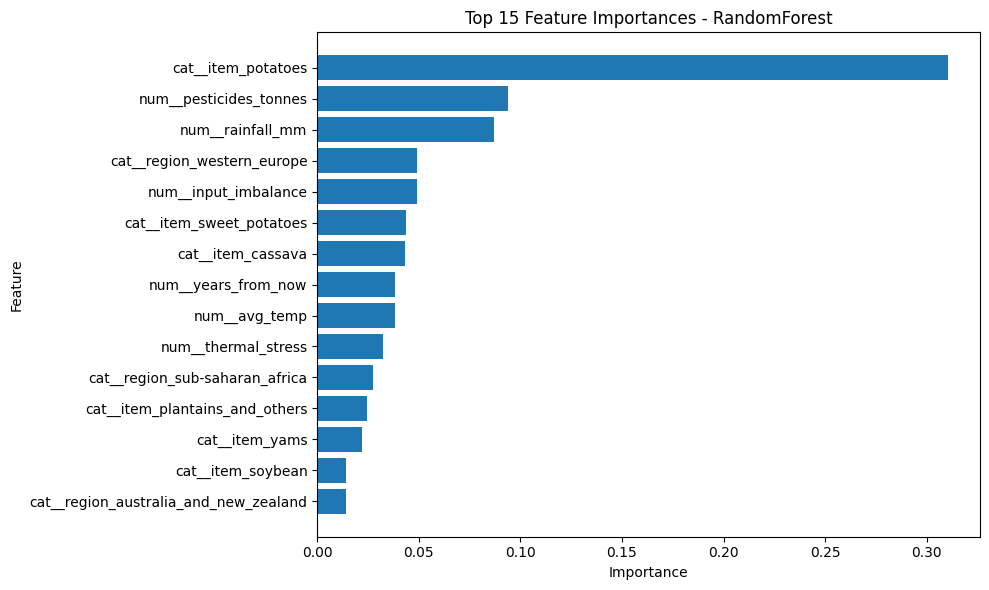


Importance par groupe :
                  group  importance
0                  item    0.489387
1  numeric_climate_tech    0.300780
2                region    0.168587
3                 other    0.041247


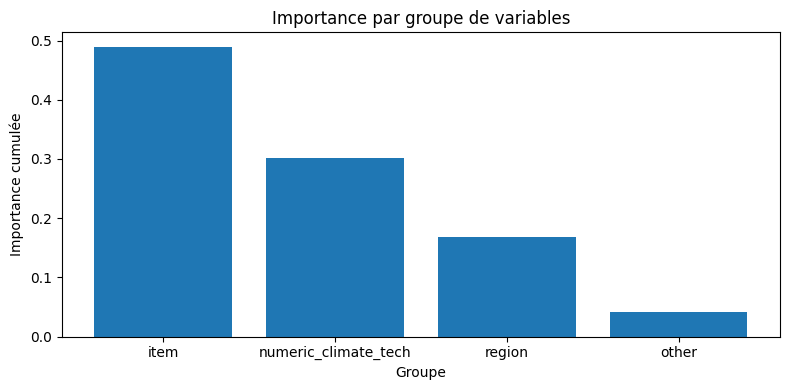

In [2]:
best_pipeline = joblib.load("../model/yield_pipeline.joblib")
# Extraire le modèle et le préprocesseur du pipeline
rf_model = best_pipeline.named_steps["model"]
preprocessor = best_pipeline.named_steps["preprocessor"]

# Récupérer les noms de variables après transformation
feature_names = preprocessor.get_feature_names_out()

# Récupérer les importances
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\nTop 15 features :")
print(feature_importance_df.head(15))

# Sauvegarder les importances si besoin

feature_importance_df.to_csv("../data/processed/feature_importance_random_forest.csv", index=False)

# Visualisation top 15

top_n = 15
top_features = feature_importance_df.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 15 Feature Importances - RandomForest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Regrouper les variables par famille métier

def feature_group(feature_name: str) -> str:

    if "avg_temp" in feature_name or "rainfall_mm" in feature_name \
       or "pesticides_tonnes" in feature_name or "input_imbalance" in feature_name \
       or "thermal_stress" in feature_name:
        return "numeric_climate_tech"
    
    if "region_" in feature_name:
        return "region"
    
    if "item_" in feature_name:
        return "item"
    
    return "other"

feature_importance_df["group"] = feature_importance_df["feature"].apply(feature_group)

group_importance_df = (
    feature_importance_df
    .groupby("group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nImportance par groupe :")
print(group_importance_df)

# Visualisation par groupe

plt.figure(figsize=(8, 4))
plt.bar(group_importance_df["group"], group_importance_df["importance"])
plt.title("Importance par groupe de variables")
plt.xlabel("Groupe")
plt.ylabel("Importance cumulée")
plt.tight_layout()
plt.show()

# Test scénario

In [12]:
def build_scenario(
    X_reference,
    region_col,
    avg_temp,
    rainfall_mm,
    pesticides_tonnes,
    tech_trend,
    climate_instability,
    relative_tech_intensity,
):
    row = X_reference.iloc[[0]].copy()

    # reset régions
    region_cols = [c for c in X_reference.columns if c.startswith("region_")]
    for c in region_cols:
        row[c] = 0

    # active la région choisie
    row[region_col] = 1

    # variables numériques
    row["avg_temp"] = avg_temp
    row["rainfall_mm"] = rainfall_mm
    row["pesticides_tonnes"] = pesticides_tonnes
    row["tech_trend"] = tech_trend
    row["climate_instability"] = climate_instability
    row["relative_tech_intensity"] = relative_tech_intensity

    return row

In [36]:
def get_crop_columns(X):
    return [col for col in X.columns if col.startswith("item_")]

def recommend_crops(input_row, model, crop_columns):
    results = []

    for crop_col in crop_columns:
        row = input_row.copy()

        for c in crop_columns:
            row[c] = 0

        row[crop_col] = 1

        pred = model.predict(row)[0]

        results.append({
            "crop": crop_col.replace("item_", ""),
            "predicted_yield": pred
        })

    return (
        pd.DataFrame(results)
        .sort_values("predicted_yield", ascending=False)
        .reset_index(drop=True)
    )

In [37]:
# best_pipeline = mlflow.sklearn.load_model("models:/Yield_Forecaster_GridSearch/latest")

df = pd.read_csv("../data/processed/yield_df_final_conso_encoded.csv", index_col=0)
X_train, X_test, y_train, y_test, categorical_cols, numeric_cols = separation_X_y(df)

crop_cols = get_crop_columns(X_test)

scenarios = {
    "chaud_sec_faible_tech": build_scenario(
        X_reference=X_test,
        region_col="region_sub-saharan_africa",
        avg_temp=28,
        rainfall_mm=400,
        pesticides_tonnes=20,
        tech_trend=0.3,
        climate_instability=0.8,
        relative_tech_intensity=0.3,
    ),
    "tempere_humide_tech_moyenne": build_scenario(
        X_reference=X_test,
        region_col="region_western_europe",
        avg_temp=16,
        rainfall_mm=900,
        pesticides_tonnes=80,
        tech_trend=0.6,
        climate_instability=0.3,
        relative_tech_intensity=0.7,
    ),
    "chaud_humide_tech_forte": build_scenario(
        X_reference=X_test,
        region_col="region_south-eastern_asia",
        avg_temp=26,
        rainfall_mm=1400,
        pesticides_tonnes=100,
        tech_trend=0.8,
        climate_instability=0.4,
        relative_tech_intensity=0.9,
    ),
    "scenario_desert": build_scenario(
    X_reference=X_test,
    region_col="region_northern_africa",
    avg_temp=32,
    rainfall_mm=150,
    pesticides_tonnes=10,
    tech_trend=0.2,
    climate_instability=0.9,
    relative_tech_intensity=0.2,
),
"scenario_tropical" : build_scenario(
    X_reference=X_test,
    region_col="region_south-eastern_asia",
    avg_temp=27,
    rainfall_mm=1800,
    pesticides_tonnes=70,
    tech_trend=0.6,
    climate_instability=0.5,
    relative_tech_intensity=0.7,
)
}

for scenario_name, scenario_row in scenarios.items():
    recs = recommend_crops(scenario_row, best_pipeline, crop_cols)
    print(f"\n=== {scenario_name} ===")
    print(recs.head(5))

2026-04-03 11:43:21,022 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-03 11:43:21,022 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams', 'is_drought_false', 'is_drought_true']



=== chaud_sec_faible_tech ===
                   crop  predicted_yield
0        sweet_potatoes    163137.627132
1              potatoes    136016.500000
2                  yams    107235.823021
3               cassava     79774.479479
4  plantains_and_others     73047.708437

=== tempere_humide_tech_moyenne ===
                   crop  predicted_yield
0              potatoes    292247.724167
1               cassava    103136.374479
2        sweet_potatoes     99379.235691
3  plantains_and_others     88811.058958
4                  yams     88426.658283

=== chaud_humide_tech_forte ===
                   crop  predicted_yield
0              potatoes    171302.897776
1               cassava    133138.497540
2  plantains_and_others    101655.220463
3        sweet_potatoes     89220.073297
4                  yams     74031.516194

=== scenario_desert ===
                   crop  predicted_yield
0              potatoes    166867.037292
1        sweet_potatoes    161118.820000
2            

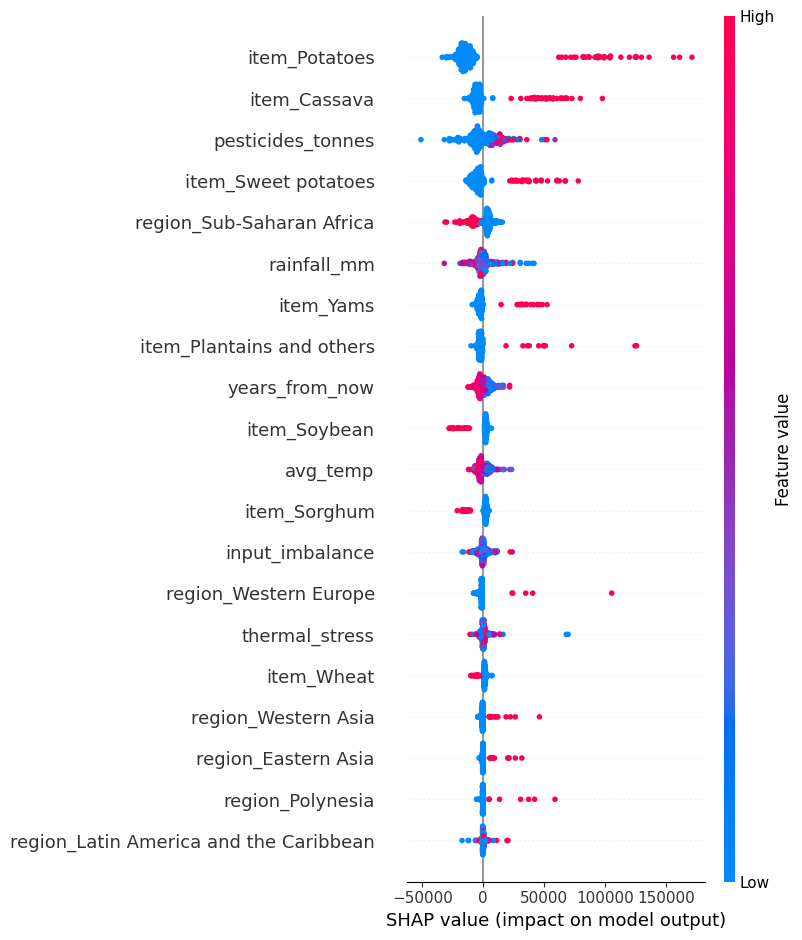

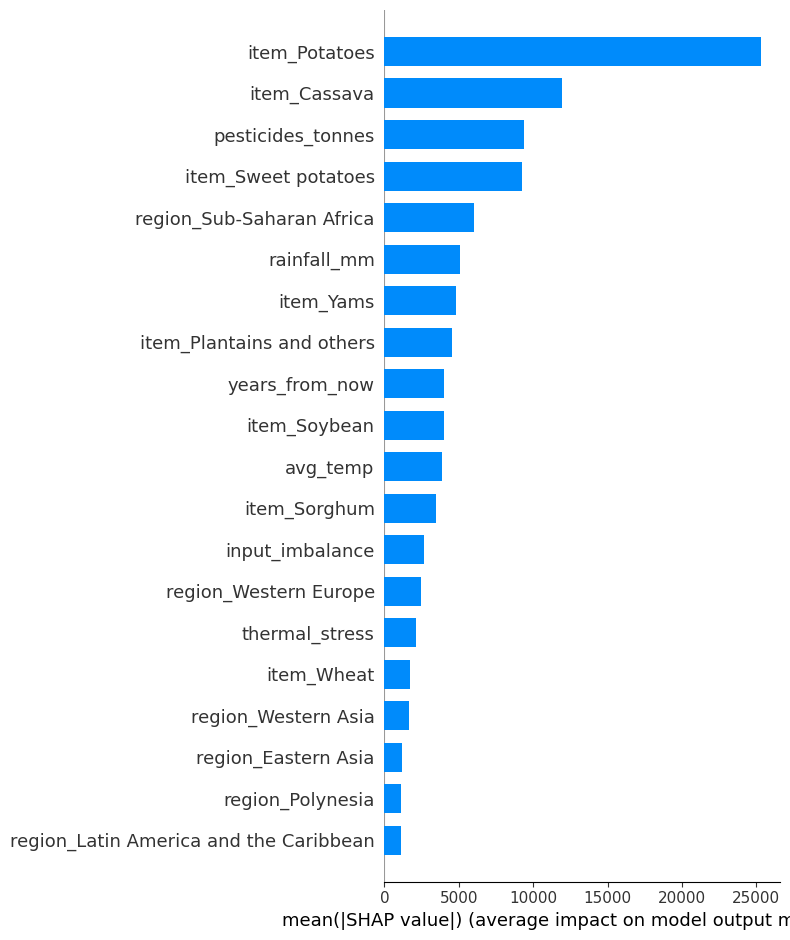

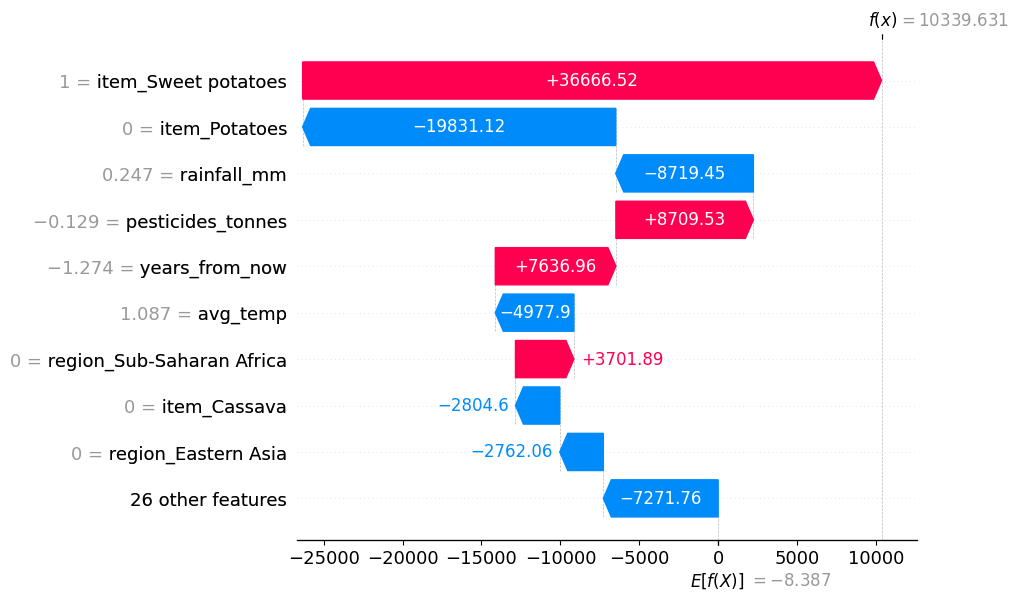

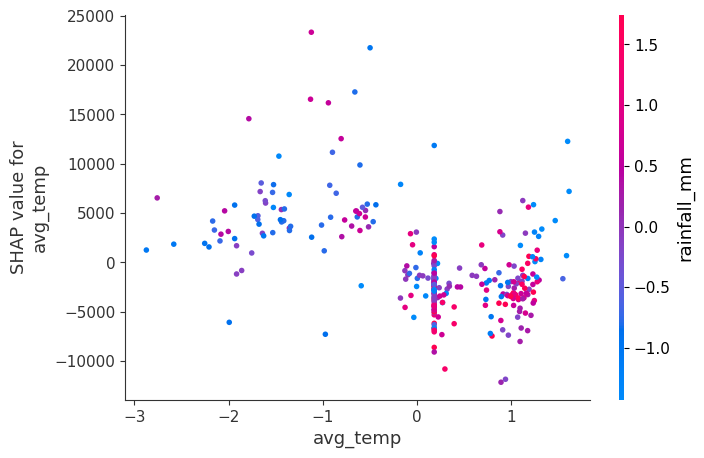

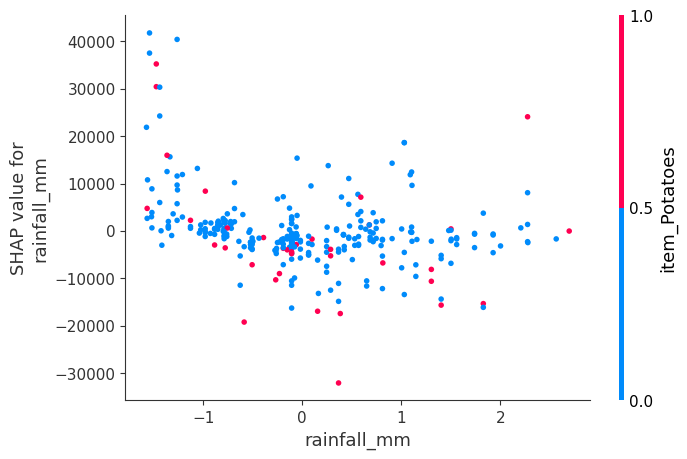

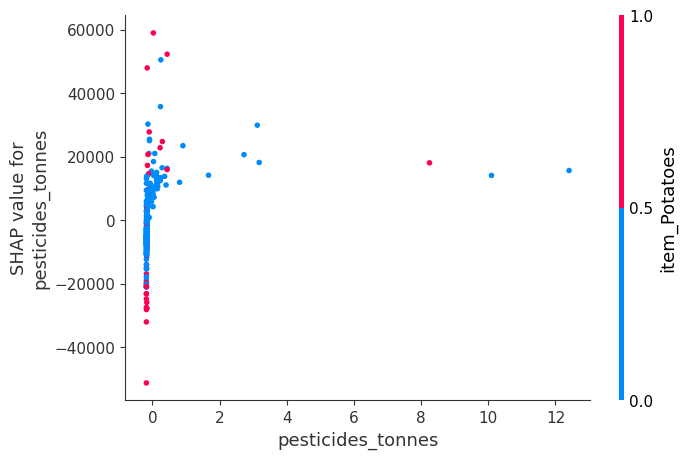

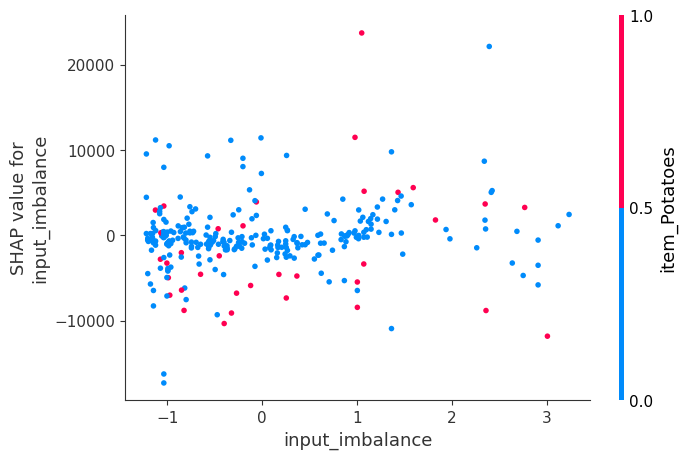

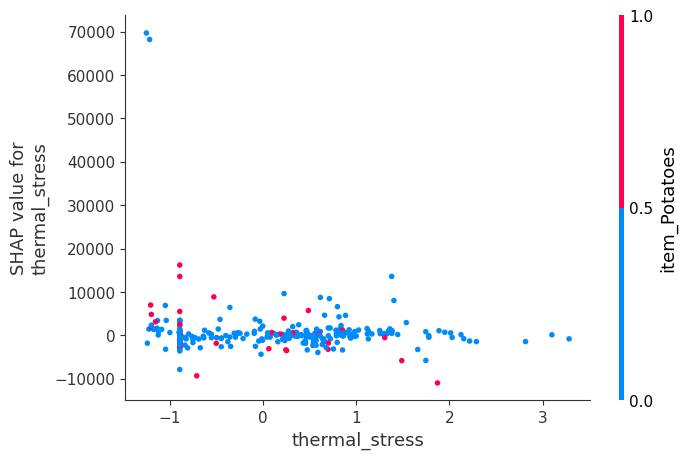

In [2]:
import joblib
import shap
import pandas as pd

# =========================
# 1. Rechargement des objets
# =========================
X_shap = joblib.load("../model/X_shap_300.joblib")
shap_values = joblib.load("../model/shap_values_300.joblib")

# =========================
# 2. Nettoyage des noms (optionnel mais recommandé)
# =========================
X_shap_plot = X_shap.copy()
X_shap_plot.columns = [
    col.replace("num__", "").replace("cat__", "")
    for col in X_shap_plot.columns
]

# =========================
# 3. Graphiques SHAP
# =========================

# 🔹 1. Importance globale (le plus important)
shap.summary_plot(shap_values, X_shap_plot)

# 🔹 2. Importance simple (bar)
shap.summary_plot(shap_values, X_shap_plot, plot_type="bar")

# 🔹 3. Explication d’une prédiction individuelle
idx = 0

# Recréer un objet Explanation (important après reload)
explainer_base_value = shap_values.mean()

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer_base_value,
        data=X_shap_plot.iloc[idx],
        feature_names=X_shap_plot.columns
    )
)

# 🔹 4. Force plot (optionnel, parfois capricieux)
shap.initjs()

shap.force_plot(
    explainer_base_value,
    shap_values[idx],
    X_shap_plot.iloc[idx]
)

# 🔹 5. Dependence plot (effet d'une variable)
important_features = X_shap_plot.columns[:5]

for feature in important_features:
    shap.dependence_plot(feature, shap_values, X_shap_plot)